In [6]:
import pdb
import glob
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
%matplotlib inline

import inversion_tools

pdir  = '/work/noaa/co2/jhollo/processed_transport_data/'
ddir  = '/home/jhollo/wombat_stuff_link/wombat-v3-forward/4a_postprocessing_gc/intermediates/monthly-fluxes'

weighted_lat_avg = lambda data: data.weighted(np.cos(np.deg2rad(data.lat))).mean('lat')
lon_avg          = lambda data: data.mean('lon')
horz_avg         = lambda data: lon_avg(weighted_lat_avg(data))

pfts = [
    (1, "DBG", "Desert and Bare Ground"),
    (2, "ENF", "Evergreen Needleleaf Forest"),
    (3, "DNF", "Deciduous Needleleaf Forest"),
    (4, "EBF", "Evergreen Broadleaf Forest"),
    (5, "DBF", "Deciduous Broadleaf Forest"),
    (6, "SHB", "Shrubs (Non-Tundra)"),
    (7, "SHA", "Tundra Shrubs"),
    (8, "C3A", "Tundra Grassland"),
    (9, "C3G", "C3 Grassland"),
    (10, "C4G", "C4 Grassland"),
    (11, "C3C", "C3 Generic Crop"),
    (12, "C4C", "C4 Generic Crop"),
    (13, "MZE", "Maize"),
    (14, "SOY", "Soybeans"),
    (15, "WWT", "Winter Wheat"),
]

In [7]:
def get_gpp_intercept(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_intercept_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp
def get_gpp(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    resp_files = sorted(glob.glob(f'{ddir}/bio_resp_tot_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    resp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in resp_files], 'time')
    resp = resp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp
def get_gpp_latlon(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    resp_files = sorted(glob.glob(f'{ddir}/bio_resp_tot_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([xr.open_dataset(f)['flux'] for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    resp = xr.concat([xr.open_dataset(f)['flux'] for f in resp_files], 'time')
    resp = resp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp

### First let's inspect the regional mean residual time series for a few select regions and PFTs

Text(0, 0.5, 'gpp residual [g m2/day]')

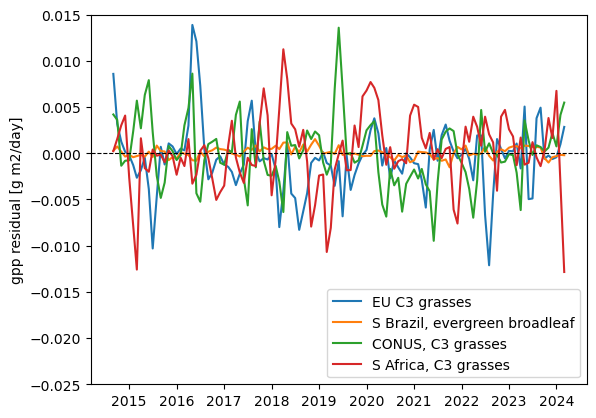

In [12]:
gpp = get_gpp(11, 9) # eu, C3 grasses
plt.plot(gpp.time, -gpp, label='EU C3 grasses')
gpp = get_gpp(4, 4) # S brazil, evergreen broadleaf
plt.plot(gpp.time, -gpp, label='S Brazil, evergreen broadleaf')
gpp = get_gpp(2, 9) # conus, C3 grasses
plt.plot(gpp.time, -gpp, label='CONUS, C3 grasses')
gpp = get_gpp(6, 9) # S africa, C3 grasses
plt.plot(gpp.time, -gpp, label='S Africa, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.legend(loc='lower right')
plt.ylim([-0.025, 0.015])
plt.ylabel('gpp residual [g m2/day]')

### Now looking at just C3 grasses and crops in Europe. 
#### A red dashed line marks the drought of June 2020, which produced gpp anomalies of up to -3 g/m2/day (or gpp-associated emissions of 3 g/m2/day), according to Qiu et al. (2025)

Text(0, 0.5, 'gpp residual [g m2/day]')

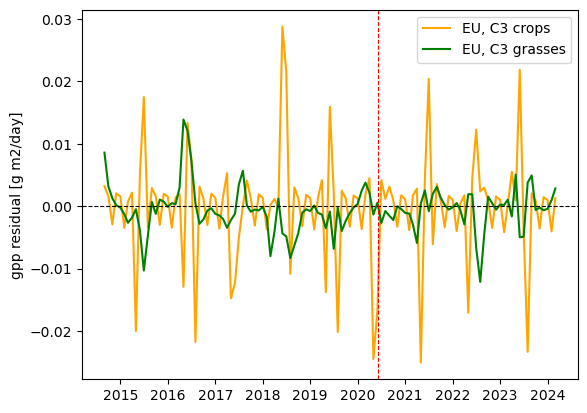

In [13]:
gpp = get_gpp(11, 11) # eu, C3 crops
plt.plot(gpp.time, -gpp, 'orange', label='EU, C3 crops')
gpp = get_gpp(11, 9) # eu, C3 grasses
plt.plot(gpp.time, -gpp, 'g', label='EU, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.axvline(x=np.datetime64("2020-06-03"), linestyle='--', color='r', linewidth=0.8)
plt.legend()
plt.ylabel('gpp residual [g m2/day]')

### Now looking at just C3 grasses and crops in the US. 
#### A red dashed line marks the drought of July 2021, which produced gpp anomalies of up to +/-3 g/m2/day (or gpp-associated emissions of -/+ 3 g/m2/day), according to Qiu et al. (2025)

Text(0, 0.5, 'gpp residual [g m2/day]')

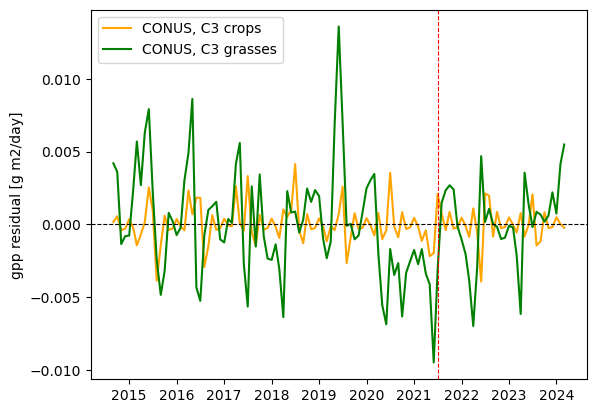

In [16]:
gpp = get_gpp(2, 11) # conus, C3 crops
plt.plot(gpp.time, -gpp, 'orange', label='CONUS, C3 crops')
gpp = get_gpp(2, 9) # conus, C3 grasses
plt.plot(gpp.time, -gpp, 'g', label='CONUS, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.axvline(x=np.datetime64("2021-07-02"), linestyle='--', color='r', linewidth=0.8)
plt.legend()
plt.ylabel('gpp residual [g m2/day]')

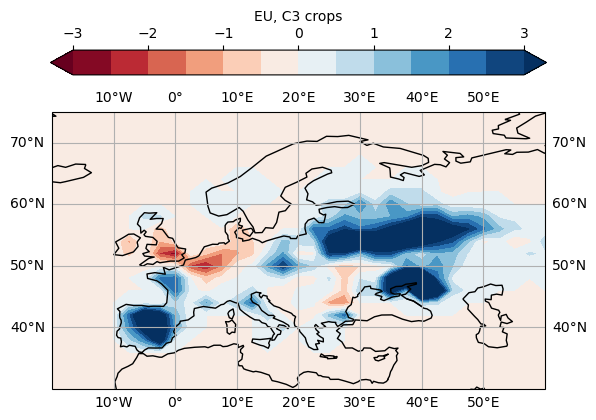

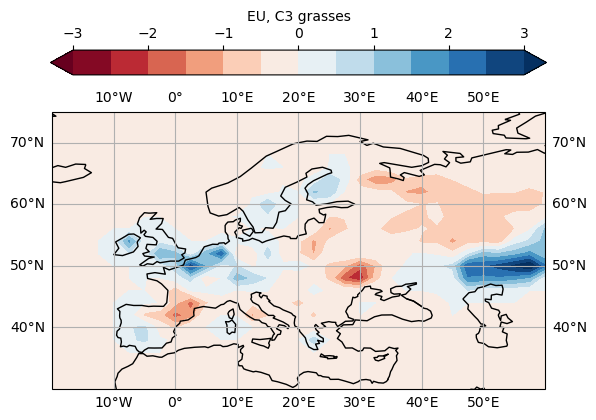

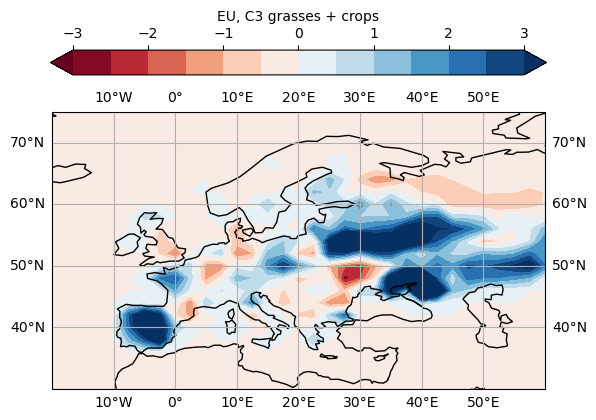

In [72]:
levels = np.arange(-3, 3.1, 0.5)

gpp = get_gpp_latlon(11, 11) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 crops', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

gpp = get_gpp_latlon(11, 9) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 grasses', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

gpp = get_gpp_latlon(11, 9) +  get_gpp_latlon(11, 11) # eu, all C3
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 grasses + crops', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

In [82]:
levels = np.arange(-3, 3.1, 0.5)
bad_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(11, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(11, pft)
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=np.datetime64("2020-06-03"), method='nearest')

skipping pft 1
skipping pft 3
skipping pft 4
skipping pft 6
skipping pft 10
skipping pft 12
skipping pft 14


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


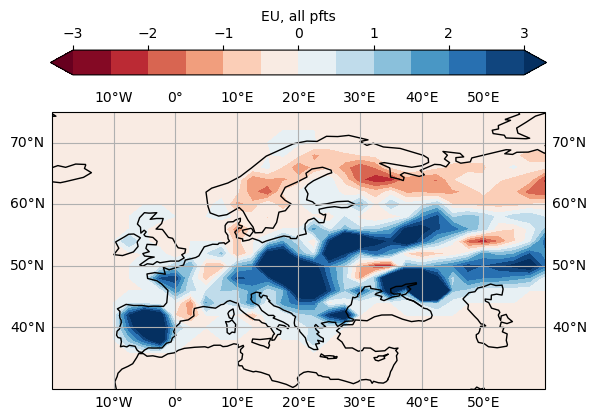

In [83]:
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, all pfts', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

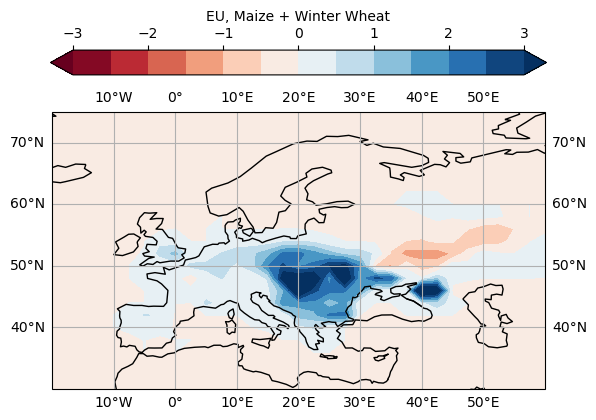

In [96]:
gpp = get_gpp_latlon(11, 13) + get_gpp_latlon(11, 15) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, Maize + Winter Wheat', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

In [84]:
levels = np.arange(-3, 3.1, 0.5)
bad_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(2, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(2, pft)
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=np.datetime64("2021-07-02"), method='nearest')

skipping pft 1
skipping pft 3
skipping pft 4
skipping pft 7
skipping pft 8
skipping pft 12


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


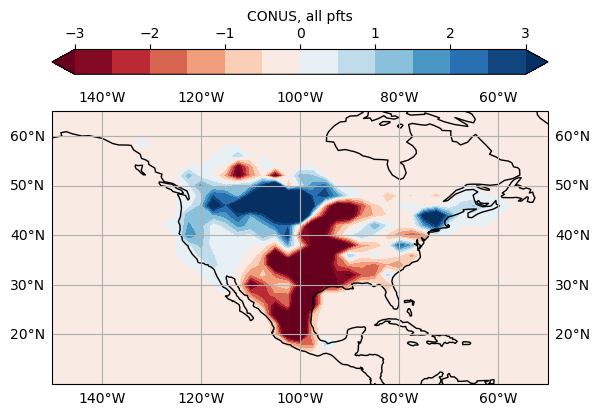

In [88]:
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='CONUS, all pfts', location='top', pad=0.1)
ax.set_extent([-150, -50, 10, 65], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

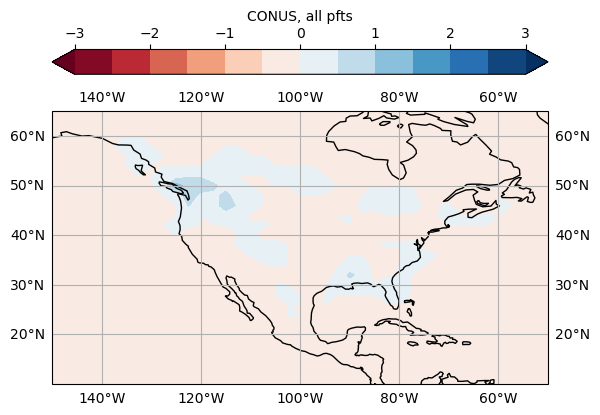

In [123]:
gpp = get_gpp_latlon(2, 2) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='CONUS, all pfts', location='top', pad=0.1)
ax.set_extent([-150, -50, 10, 65], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

### Checking for a signature of the Siberian Heat Wave of 2021

In [8]:
levels = np.arange(-3, 3.1, 0.5)
bad_pfts = []
kept_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(7, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(7, pft)
        kept_pfts.append(int(pft))
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=slice(np.datetime64("2020-05-31"), np.datetime64("2020-07-31"))).mean('time')

skipping pft 1
skipping pft 4
skipping pft 6
skipping pft 10
skipping pft 11
skipping pft 12
skipping pft 13
skipping pft 14


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


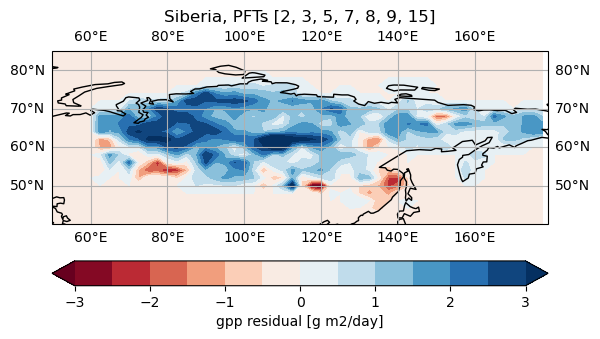

In [9]:
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, -gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='gpp residual [g m2/day]', location='bottom', pad=0.1)
ax.set_extent([50, 179, 40, 85], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)
ax.set_title(f'Siberia, PFTs {kept_pfts}')

plt.savefig('siberia_gpp_anomaly_map.png', dpi=200)


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

In [10]:
gpp = []
tslice = time=slice(np.datetime64("2020-05-31"), np.datetime64("2020-07-31"))
for pfti in kept_pfts:
    gpp.append(get_gpp_latlon(7, pfti).sel(time=tslice).mean('time'))
gpp = xr.concat(gpp, dim='pft')
gpp = gpp.assign_coords(pft=kept_pfts)
gpp_dom = np.abs(gpp).argmax('pft')
gpp_dom = gpp_dom.where(gpp.sum('pft') != 0)

,npft,clen,PFT
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
14,15,WWT,Winter Wheat


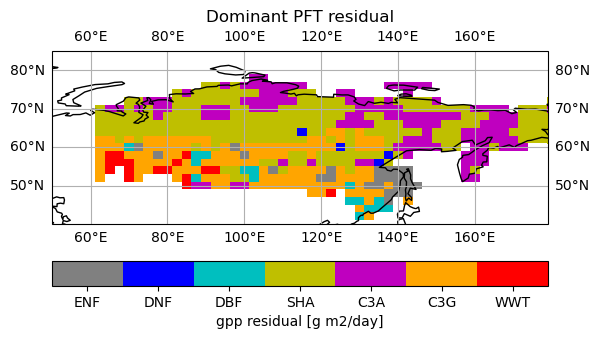

In [11]:
edges = np.arange(0, len(kept_pfts)+1, 1)
mid = edges[:-1] + np.diff(edges) / 2
colors = ['grey', 'b', 'c', 'y', 'm', 'orange', 'r']

cmap = ListedColormap(colors)
norm = BoundaryNorm(edges, cmap.N)

fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.pcolormesh(gpp.lon, gpp.lat, gpp_dom, cmap=cmap, norm=norm)
cb  = fig.colorbar(cf, ax=ax, label='gpp residual [g m2/day]', location='bottom', pad=0.1)
cb.set_ticks(mid)
cb.ax.tick_params(which="minor", length=0)
cb.set_ticklabels([f'{pfts[p-1][1]}' for p in kept_pfts])
ax.set_extent([50, 179, 40, 85], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)
ax.set_title(f'Dominant PFT residual')

plt.savefig('siberia_gpp_anomaly_pfts_maps.png', dpi=200)

df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
df = df[df['npft'].isin(kept_pfts)]
df

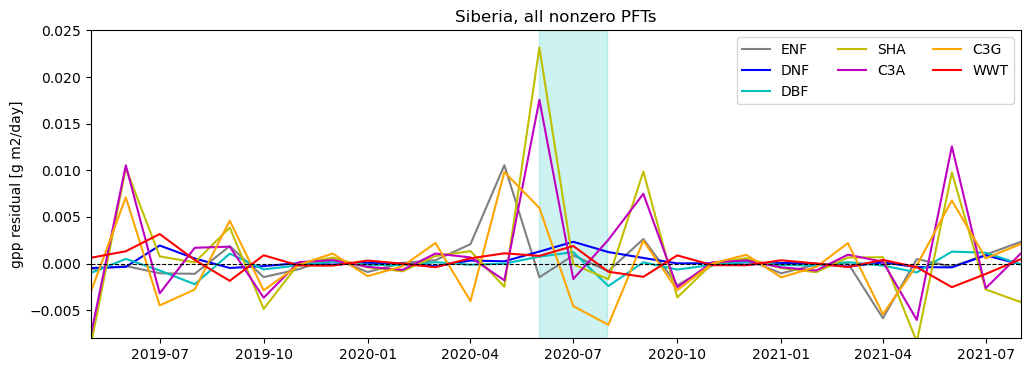

In [13]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)
for i,pfti in enumerate(kept_pfts):
    gpp = get_gpp(7, pfti) 
    ax.plot(gpp.time, -gpp, color=colors[i], label=f'{pfts[pfti-1][1]}')
ax.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
ax.axvspan(np.datetime64("2020-06-01"), np.datetime64("2020-07-31"), color='c', alpha=0.2)
plt.legend(ncol=3)
ax.set_xlim([np.datetime64("2019-05-01"), np.datetime64("2021-08-01")])
ax.set_ylabel('gpp residual [g m2/day]')
ax.set_ylim([-0.008, 0.025])
ax.set_title('Siberia, all nonzero PFTs')

plt.savefig('siberia_gpp_anomaly_pfts_timeseries.png', dpi=200)

Text(0.5, 1.0, 'Siberia, all tree PFTs')

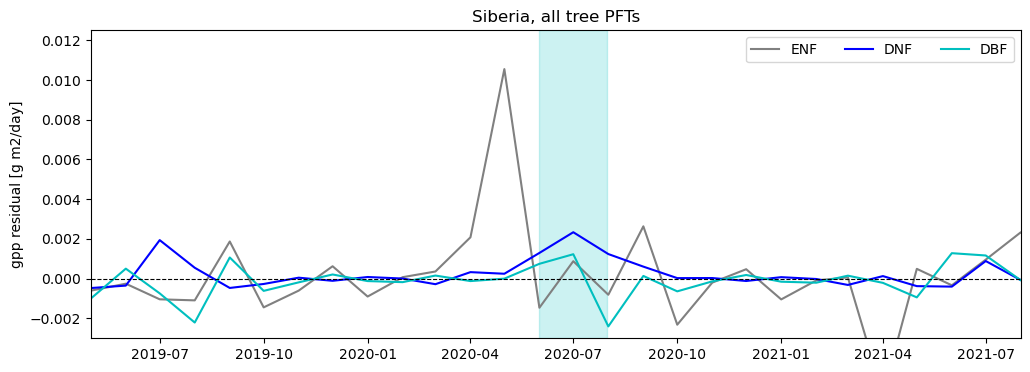

In [147]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)
for i,pfti in enumerate([2, 3, 5]):
    gpp = get_gpp(7, pfti) 
    ax.plot(gpp.time, -gpp, color=colors[i], label=f'{pfts[pfti-1][1]}')
ax.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
ax.axvspan(np.datetime64("2020-06-01"), np.datetime64("2020-07-31"), color='c', alpha=0.2)
plt.legend(ncol=3)
ax.set_xlim([np.datetime64("2019-05-01"), np.datetime64("2021-08-01")])
ax.set_ylabel('gpp residual [g m2/day]')
ax.set_ylim([-0.003, 0.0125])
ax.set_title('Siberia, all tree PFTs')

### Checking for a signature of the Australian Heat Wave of 2017

Text(0.5, 1.0, 'Australia, all nonzero natural PFTs')

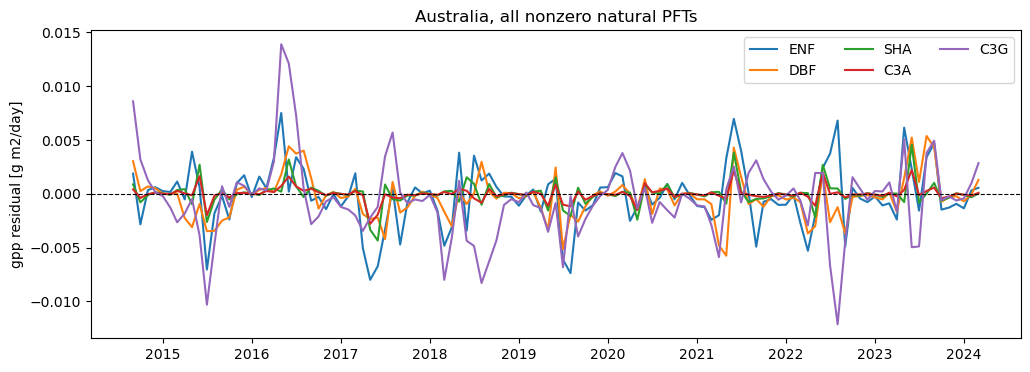

In [160]:
kept_pfts = np.arange(0, len(pfts))+1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)
for i,pfti in enumerate(kept_pfts):
    if(pfti>=11): continue
    try:
        gpp = get_gpp(11, pfti) 
    except ValueError:
        continue
    ax.plot(gpp.time, -gpp, label=f'{pfts[pfti-1][1]}')
ax.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
#ax.axvspan(np.datetime64("2020-06-01"), np.datetime64("2020-07-31"), color='c', alpha=0.2)
plt.legend(ncol=3)
#ax.set_xlim([np.datetime64("2015-09-01"), np.datetime64("2017-01-01")])
ax.set_ylabel('gpp residual [g m2/day]')
#ax.set_ylim([-0.008, 0.025])
ax.set_title('Australia, all nonzero natural PFTs')

In [167]:
bad_pfts = []
kept_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(10, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(10, pft)
        kept_pfts.append(int(pft))
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=slice(np.datetime64("2016-05-01"), np.datetime64("2016-07-01"))).mean('time')

skipping pft 1
skipping pft 3
skipping pft 7
skipping pft 8
skipping pft 11
skipping pft 12
skipping pft 13
skipping pft 14


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


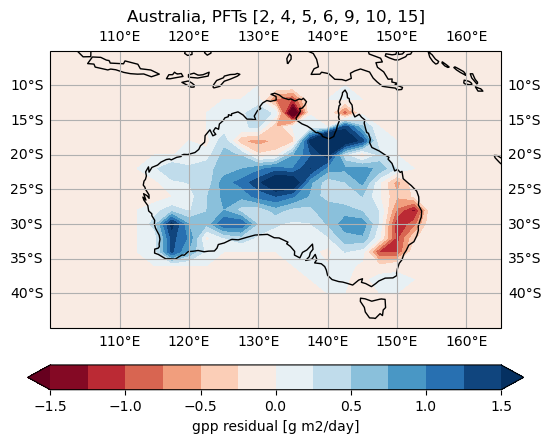

In [168]:
levels = np.arange(-1.5, 1.6, 0.25)
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, -gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='gpp residual [g m2/day]', location='bottom', pad=0.1)
ax.set_extent([100, 165, -45, -5], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)
ax.set_title(f'Australia, PFTs {kept_pfts}')


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

In [171]:
gpp = []
tslice = time=slice(np.datetime64("2016-05-01"), np.datetime64("2016-07-01"))
for pfti in kept_pfts:
    gpp.append(get_gpp_latlon(10, pfti).sel(time=tslice).mean('time'))
gpp = xr.concat(gpp, dim='pft')
gpp = gpp.assign_coords(pft=kept_pfts)
gpp_dom = np.abs(gpp).argmax('pft')
gpp_dom = gpp_dom.where(gpp.sum('pft') != 0)

,npft,clen,PFT
1,2,ENF,Evergreen Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland
14,15,WWT,Winter Wheat


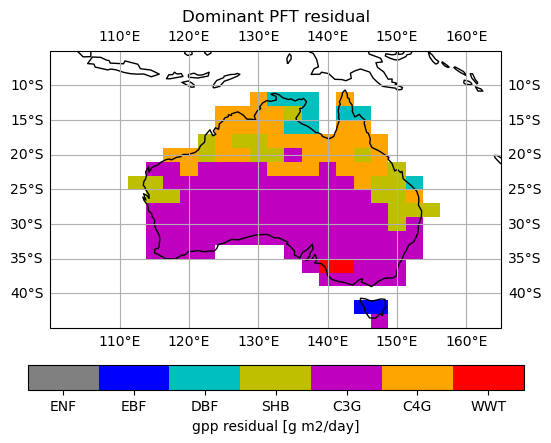

In [172]:
edges = np.arange(0, len(kept_pfts)+1, 1)
mid = edges[:-1] + np.diff(edges) / 2
colors = ['grey', 'b', 'c', 'y', 'm', 'orange', 'r']

cmap = ListedColormap(colors)
norm = BoundaryNorm(edges, cmap.N)

fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.pcolormesh(gpp.lon, gpp.lat, gpp_dom, cmap=cmap, norm=norm)
cb  = fig.colorbar(cf, ax=ax, label='gpp residual [g m2/day]', location='bottom', pad=0.1)
cb.set_ticks(mid)
cb.ax.tick_params(which="minor", length=0)
cb.set_ticklabels([f'{pfts[p-1][1]}' for p in kept_pfts])
ax.set_extent([100, 165, -45, -5], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)
ax.set_title(f'Dominant PFT residual')

df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
df = df[df['npft'].isin(kept_pfts)]
df

Text(0.5, 1.0, 'Australia, all nonzero natural PFTs')

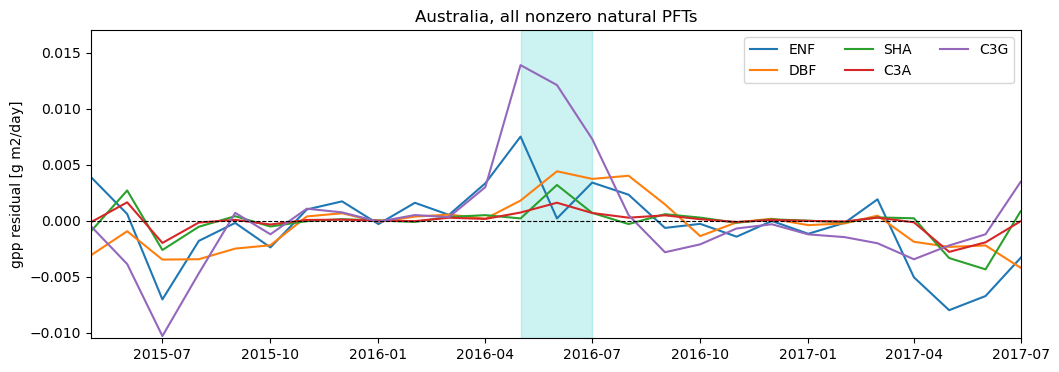

In [178]:
kept_pfts = np.arange(0, len(pfts))+1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(111)
for i,pfti in enumerate(kept_pfts):
    if(pfti>=11): continue
    try:
        gpp = get_gpp(11, pfti) 
    except ValueError:
        continue
    ax.plot(gpp.time, -gpp, label=f'{pfts[pfti-1][1]}')
ax.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
ax.axvspan(np.datetime64("2016-05-01"), np.datetime64("2016-07-01"), color='c', alpha=0.2)
plt.legend(ncol=3)
ax.set_xlim([np.datetime64("2015-05-01"), np.datetime64("2017-07-01")])
ax.set_ylabel('gpp residual [g m2/day]')
ax.set_ylim([-0.0105, 0.017])
ax.set_title('Australia, all nonzero natural PFTs')